<a href="https://colab.research.google.com/github/thaiyalvishu97/MyProjects/blob/main/Driver_analysis_deep_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Vehicle Telemetry for Driver Behavior Analysis

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("Driver_Behavior.csv")

In [3]:
df.isnull().sum()

,0
speed_kmph,0
accel_x,0
accel_y,0
brake_pressure,0
steering_angle,0
throttle,0
lane_deviation,0
phone_usage,0
headway_distance,0
reaction_time,0


In [4]:
le = LabelEncoder()
df['behavior_label'] = le.fit_transform(df['behavior_label'])

In [5]:
df

,speed_kmph,accel_x,accel_y,brake_pressure,steering_angle,throttle,lane_deviation,phone_usage,headway_distance,reaction_time,behavior_label
0,36.075011,0.535763,0.708633,23.107812,-3.169956,53.123505,0.851871,1,17.996005,1.400050,1
1,38.090536,0.973764,0.044312,36.961137,-24.380082,36.383904,1.459495,1,29.904182,1.428537,1
2,71.314445,3.638434,0.789375,79.734087,-6.100238,78.110507,0.254723,0,11.126012,0.406950,0
3,86.485997,2.441366,0.039135,45.007002,17.886191,82.794935,0.911664,0,11.064505,0.539964,0
4,52.816777,-0.201763,0.560619,38.759612,-4.104323,61.432375,1.591244,1,21.967570,1.369908,1
...,...,...,...,...,...,...,...,...,...,...,...
29995,53.793871,0.630921,0.338402,26.264227,1.380436,32.252103,0.934973,1,27.011128,1.765279,1
29996,47.963150,0.578964,0.073692,22.825827,9.846702,34.785630,0.255194,0,42.445077,0.710229,2
29997,49.804551,1.377664,0.546392,49.951452,7.958562,39.792856,0.524941,1,25.878929,1.449100,1
29998,44.326306,0.421080,0.127109,0.738540,12.019311,29.867322,0.309540,0,41.039219,0.711371,2


In [6]:
df.groupby('behavior_label').mean()

,speed_kmph,accel_x,accel_y,brake_pressure,steering_angle,throttle,lane_deviation,phone_usage,headway_distance,reaction_time
behavior_label,,,,,,,,,,
0,75.040534,2.498725,0.604583,69.910588,-0.076387,79.940690,0.501683,0.0,12.548194,0.550268
1,50.074158,0.797889,0.399970,39.932205,-0.061568,50.048691,1.002635,1.0,20.107848,1.598786
2,54.844581,0.500841,0.100951,12.460078,0.017333,35.014288,0.201328,0.0,37.541489,0.850397


In [7]:
X = df.drop(columns='behavior_label',axis=1)
Y = df['behavior_label']
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

In [8]:
scaler = StandardScaler()
X_train= scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [9]:
import tensorflow as tf
import keras
tf.random.set_seed(3)

In [10]:
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(10,)),
    keras.layers.Dense(12,activation='relu'),
    keras.layers.Dense(3,activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [11]:
model.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

In [12]:
history = model.fit(X_train,Y_train,validation_split=0.1,epochs=10)

Epoch 1/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9355 - loss: 0.2206 - val_accuracy: 1.0000 - val_loss: 0.0132
Epoch 2/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9999 - loss: 0.0069 - val_accuracy: 1.0000 - val_loss: 0.0031
Epoch 3/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 1.0000 - loss: 0.0022 - val_accuracy: 1.0000 - val_loss: 0.0012
Epoch 4/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 1.0000 - loss: 0.0010 - val_accuracy: 1.0000 - val_loss: 6.2562e-04
Epoch 5/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 1.0000 - loss: 5.5945e-04 - val_accuracy: 1.0000 - val_loss: 3.4892e-04
Epoch 6/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 1.0000 - loss: 3.3160e-04 - val_accuracy: 1.0000 - val_loss: 2.0718e-04
Epoch 7/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 1.0000 - loss: 2.0654e-04 - val_accuracy: 1.0000 - val_loss: 1.2819e-04
Epoch 8/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 1.0000 - los

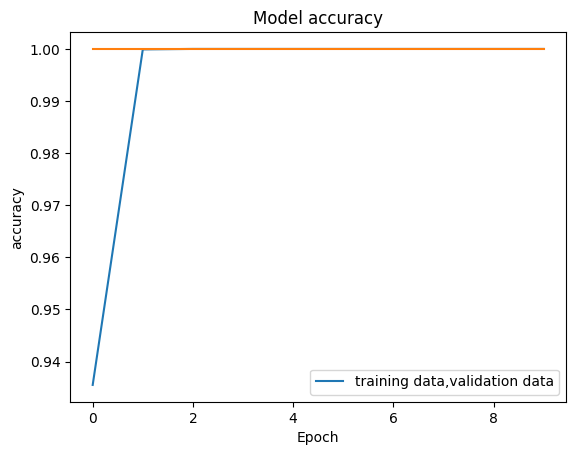

In [13]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('accuracy')
plt.xlabel('Epoch')
plt.legend(['training data,validation data'],loc='lower right')

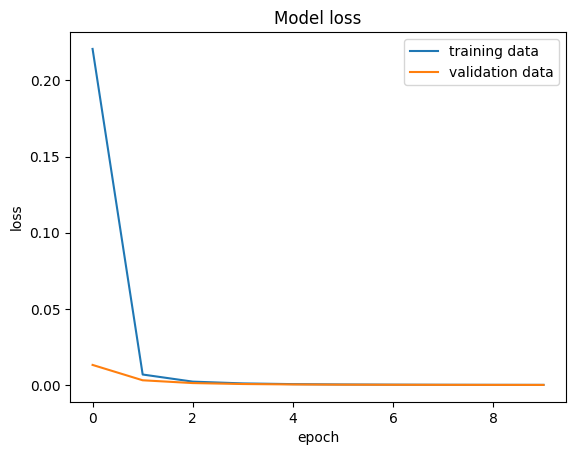

In [14]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['training data','validation data'],loc='upper right')

In [15]:
loss, accuracy = model.evaluate(X_test,Y_test)
print(accuracy)

188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 4.9738e-05
1.0


In [16]:
Y_pred = model.predict(X_test)
print(Y_pred)

188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
[[2.7690984e-02 4.7237899e-02 9.9985951e-01]
 [4.4508623e-05 9.9978739e-01 1.8233735e-04]
 [9.9733078e-01 3.7743549e-03 6.8216491e-03]
 ...
 [9.9001551e-01 1.2601740e-02 2.4952665e-02]
 [2.0109253e-02 5.6361865e-02 9.9966544e-01]
 [9.9973971e-01 5.6174968e-04 2.7223452e-04]]


In [17]:
Y_pred_max = np.argmax(Y_pred)
print(Y_pred_max)

9218


In [18]:
input_data = [[53.793871,0.630921,0.338402,26.264227,1.380436,32.252103,0.934973,1,27.011128,1.765279]]
input_num_arr = np.asarray(input_data)
input_num_arr_reshaped = input_num_arr.reshape(1,-1)
input_num_arr_scaled = scaler.transform(input_num_arr_reshaped)
prediction = model.predict(input_num_arr_scaled)
prediction_max = np.argmax(prediction)
if prediction_max == 0:
  print("Driver Behavior is Aggressive")
elif prediction_max == 1:
  print("Driver Behavior is Distracted")
elif prediction_max == 2:
  print("Driver Behavior is Safe")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
Driver Behavior is Distracted


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
